# The Coupon Paradox: VIP Campaign Simulation

**Article:** [The Coupon Paradox: Why Predicting Purchases Kills Your Margins](https://beyondcorrelation1.substack.com/p/the-coupon-paradox-why-predicting)

This notebook is the **interactive companion** to the article. Read the post for the full story — a 20% coupon campaign that breaks conversion records but leaves net margin flat, and why **prediction** is the enemy of **ROI**.

Here we simulate an e-commerce coupon campaign in Python. Run top-to-bottom to reproduce the four customer segments, the naive targeting trap, and a **T-Learner uplift model** that finds the Persuadables.

### The Experiment
1. Generate **10,000 customers** across four latent response types: **Sure Things**, **Persuadables**, **Lost Causes**, and **Sleeping Dogs**.
2. Run a randomized experiment: half receive the coupon (treatment), half do not (control).
3. **Naive strategy:** train a classifier for $P(\text{Purchase} \mid X)$ and send coupons to the top 100 predicted buyers.
4. **Uplift strategy:** estimate $\text{CATE}(x) = P(Y{=}1 \mid X{=}x, T{=}1) - P(Y{=}1 \mid X{=}x, T{=}0)$ with a T-Learner and target the top 100 uplift scores.
5. Compare conversion rate **and** net margin impact.

## Phase 1 — Generate Customers & the Four Segments

Each customer has observable features $X$ (engagement, cart activity, tenure) and a hidden response type that governs how the coupon changes their purchase probability.

Population segment summary (randomized experiment):


,share,p_control,p_treated,uplift
segment,,,,
Lost Cause,0.396,0.029,0.038,0.009
Persuadable,0.253,0.061,0.729,0.669
Sleeping Dog,0.096,0.427,0.188,-0.238
Sure Thing,0.255,0.880,0.932,0.052


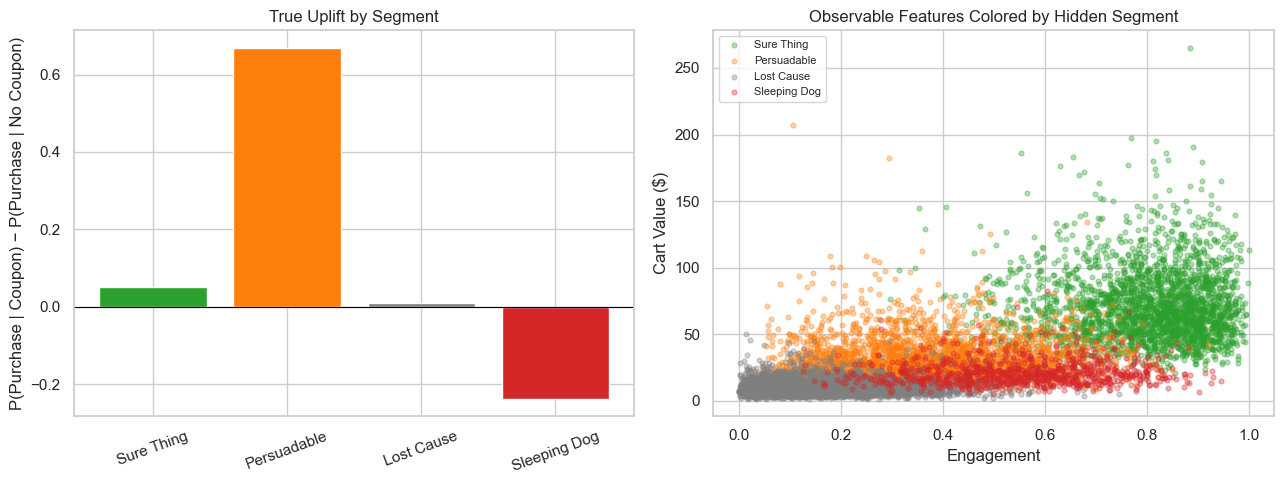

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
sns.set_theme(style="whitegrid")

N = 10_000
ORDER_VALUE = 100.0
DISCOUNT_RATE = 0.20
COUPON_COST = ORDER_VALUE * DISCOUNT_RATE
N_TARGET = 100

SEGMENTS = {
    "Sure Thing": {"share": 0.25, "p_control": 0.88, "p_treated": 0.92},
    "Persuadable": {"share": 0.25, "p_control": 0.06, "p_treated": 0.72},
    "Lost Cause": {"share": 0.40, "p_control": 0.03, "p_treated": 0.04},
    "Sleeping Dog": {"share": 0.10, "p_control": 0.42, "p_treated": 0.18},
}

segment_names = list(SEGMENTS.keys())
segment_probs = [SEGMENTS[s]["share"] for s in segment_names]
assigned_segments = np.random.choice(segment_names, size=N, p=segment_probs)

engagement = np.zeros(N)
cart_value = np.zeros(N)
tenure_months = np.zeros(N)

for seg in segment_names:
    mask = assigned_segments == seg
    n_seg = mask.sum()
    if seg == "Sure Thing":
        engagement[mask] = np.random.beta(8, 2, n_seg)
        cart_value[mask] = np.random.lognormal(mean=4.2, sigma=0.35, size=n_seg)
        tenure_months[mask] = np.random.gamma(shape=12, scale=3, size=n_seg)
    elif seg == "Persuadable":
        engagement[mask] = np.random.beta(3, 5, n_seg)
        cart_value[mask] = np.random.lognormal(mean=3.4, sigma=0.45, size=n_seg)
        tenure_months[mask] = np.random.gamma(shape=4, scale=2, size=n_seg)
    elif seg == "Lost Cause":
        engagement[mask] = np.random.beta(1.5, 8, n_seg)
        cart_value[mask] = np.random.lognormal(mean=2.2, sigma=0.5, size=n_seg)
        tenure_months[mask] = np.random.gamma(shape=2, scale=1.5, size=n_seg)
    else:  # Sleeping Dog
        engagement[mask] = np.random.beta(5, 4, n_seg)
        cart_value[mask] = np.random.lognormal(mean=3.0, sigma=0.4, size=n_seg)
        tenure_months[mask] = np.random.gamma(shape=8, scale=2, size=n_seg)

treatment = np.random.binomial(1, 0.5, size=N)

purchase_prob = np.zeros(N)
for seg in segment_names:
    mask = assigned_segments == seg
    p_ctrl = SEGMENTS[seg]["p_control"]
    p_trt = SEGMENTS[seg]["p_treated"]
    purchase_prob[mask & (treatment == 0)] = p_ctrl
    purchase_prob[mask & (treatment == 1)] = p_trt

purchase = np.random.binomial(1, purchase_prob)

df = pd.DataFrame({
    "engagement": engagement,
    "cart_value": cart_value,
    "tenure_months": tenure_months,
    "segment": assigned_segments,
    "treatment": treatment,
    "purchase": purchase,
})

feature_cols = ["engagement", "cart_value", "tenure_months"]
X = df[feature_cols].values
y = df["purchase"].values
T = df["treatment"].values

segment_summary = (
    df.groupby("segment", observed=True)
    .apply(
        lambda g: pd.Series({
            "share": len(g) / len(df),
            "p_control": g.loc[g["treatment"] == 0, "purchase"].mean(),
            "p_treated": g.loc[g["treatment"] == 1, "purchase"].mean(),
            "uplift": (
                g.loc[g["treatment"] == 1, "purchase"].mean()
                - g.loc[g["treatment"] == 0, "purchase"].mean()
            ),
        }),
        include_groups=False,
    )
    .round(3)
)

print("Population segment summary (randomized experiment):")
display(segment_summary)

palette = {
    "Sure Thing": "#2CA02C",
    "Persuadable": "#FF7F0E",
    "Lost Cause": "#7F7F7F",
    "Sleeping Dog": "#D62728",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

uplift_vals = segment_summary["uplift"].reindex(segment_names)
axes[0].bar(segment_names, uplift_vals, color=[palette[s] for s in segment_names], edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("True Uplift by Segment")
axes[0].set_ylabel("P(Purchase | Coupon) − P(Purchase | No Coupon)")
axes[0].tick_params(axis="x", rotation=20)

for seg in segment_names:
    sub = df[df["segment"] == seg]
    axes[1].scatter(
        sub["engagement"],
        sub["cart_value"],
        s=12,
        alpha=0.35,
        color=palette[seg],
        label=seg,
    )
axes[1].set_title("Observable Features Colored by Hidden Segment")
axes[1].set_xlabel("Engagement")
axes[1].set_ylabel("Cart Value ($)")
axes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

## Phase 2 — The Naive Trap: Predict Who Will Buy

The data scientist trains a standard classifier on customers who received the coupon and ranks everyone by $P(\text{Purchase} \mid X)$. Management sends coupons to the top 100 scores.

The model is *accurate* — but it overwhelmingly selects **Sure Things** who would have purchased anyway.

NAIVE TARGETING — top 100 by purchase probability
Expected conversion rate: 91.4%
Incremental conversions:  5.9
Incremental net margin:   $-1,242

Segment mix in targeted cohort:


,count
segment,
Sure Thing,97
Persuadable,3
Lost Cause,0
Sleeping Dog,0


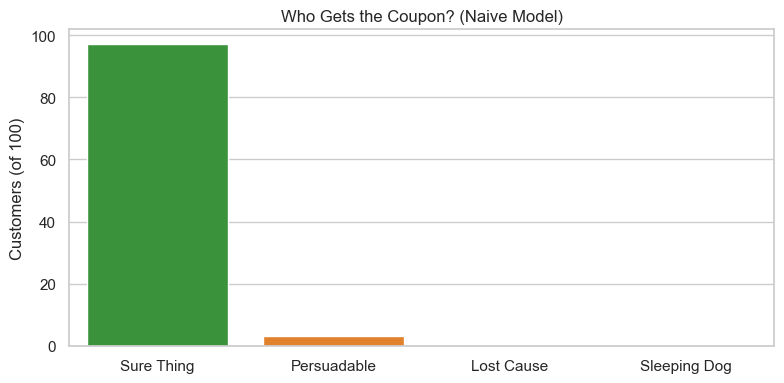

In [24]:
def fit_predict_proba(X_train, y_train, X_score):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ])
    model.fit(X_train, y_train)
    return model.predict_proba(X_score)[:, 1]


def counterfactual_outcomes(indices: np.ndarray) -> pd.DataFrame:
    """Oracle evaluation: what happens if we send a coupon to these customers?"""
    rows = []
    for idx in indices:
        seg = assigned_segments[idx]
        p_buy_no_coupon = SEGMENTS[seg]["p_control"]
        p_buy_with_coupon = SEGMENTS[seg]["p_treated"]
        rows.append({
            "segment": seg,
            "p_buy_no_coupon": p_buy_no_coupon,
            "p_buy_with_coupon": p_buy_with_coupon,
            "incremental_conv": p_buy_with_coupon - p_buy_no_coupon,
            "margin_no_coupon": p_buy_no_coupon * ORDER_VALUE,
            "margin_with_coupon": p_buy_with_coupon * (ORDER_VALUE - COUPON_COST),
            "incremental_margin": (
                p_buy_with_coupon * (ORDER_VALUE - COUPON_COST)
                - p_buy_no_coupon * ORDER_VALUE
            ),
        })
    return pd.DataFrame(rows)


def campaign_report(indices: np.ndarray, label: str) -> dict:
    cf = counterfactual_outcomes(indices)
    seg_counts = cf["segment"].value_counts().reindex(segment_names, fill_value=0)
    return {
        "strategy": label,
        "conversion_rate": cf["p_buy_with_coupon"].mean(),
        "incremental_conversions": cf["incremental_conv"].sum(),
        "total_incremental_margin": cf["incremental_margin"].sum(),
        "avg_incremental_margin_per_customer": cf["incremental_margin"].mean(),
        "segment_mix": seg_counts,
        "details": cf,
    }


# Naive model: trained only on treated customers (common in marketing analytics)
treated_mask = T == 1
naive_scores = fit_predict_proba(X[treated_mask], y[treated_mask], X)
naive_top_idx = np.argsort(naive_scores)[-N_TARGET:][::-1]
naive_report = campaign_report(naive_top_idx, "Naive P(Purchase|X)")

print("=" * 55)
print("NAIVE TARGETING — top 100 by purchase probability")
print("=" * 55)
print(f"Expected conversion rate: {naive_report['conversion_rate']:.1%}")
print(f"Incremental conversions:  {naive_report['incremental_conversions']:.1f}")
print(f"Incremental net margin:   ${naive_report['total_incremental_margin']:,.0f}")
print()
print("Segment mix in targeted cohort:")
display(naive_report["segment_mix"].to_frame("count"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(
    data=naive_report["details"],
    x="segment",
    order=segment_names,
    palette=palette,
    hue="segment",
    legend=False,
    ax=ax,
)
ax.set_title("Who Gets the Coupon? (Naive Model)")
ax.set_xlabel("")
ax.set_ylabel("Customers (of 100)")
plt.tight_layout()
plt.show()

## Phase 3 — The Uplift Fix: T-Learner CATE Estimation

Instead of asking *"Who will buy?"*, we ask *"Who is moved by the coupon?"* Using the randomized control group, a **T-Learner** fits separate models for treated and control customers, then estimates:

$$\widehat{\text{CATE}}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$$

We target customers with the highest predicted uplift — ideally the **Persuadables**.

UPLIFT TARGETING — top 100 by predicted CATE
Expected conversion rate: 72.2%
Incremental conversions:  65.4
Incremental net margin:   $5,094

Segment mix in targeted cohort:


,count
segment,
Sure Thing,1
Persuadable,99
Lost Cause,0
Sleeping Dog,0


,Strategy,Conversion Rate (%),Incremental Conversions,Incremental Margin ($)
0,Naive P(Purchase|X),91.4,5.9,-1242.0
1,T-Learner CATE,72.2,65.4,5094.0


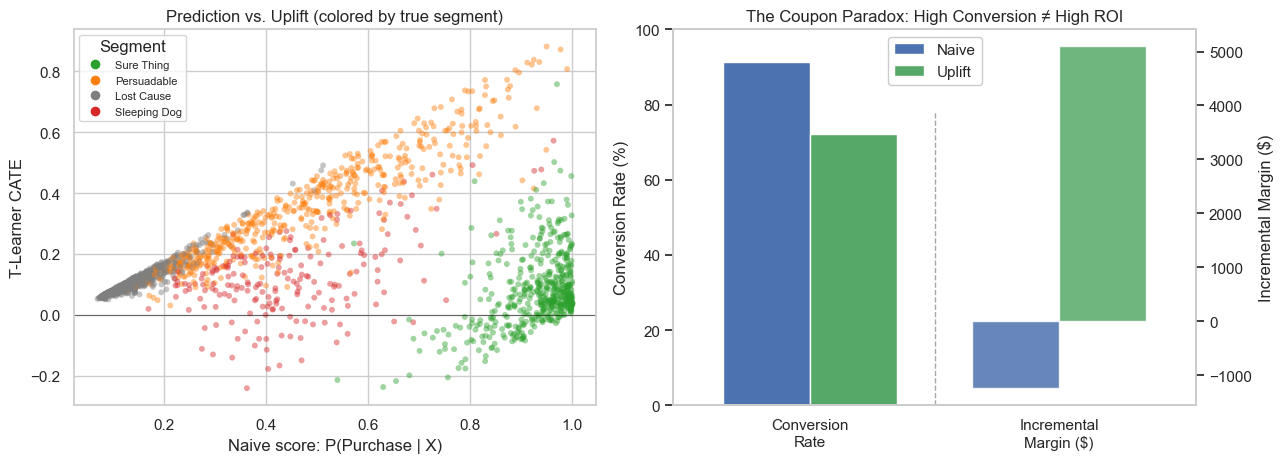

-------------------------------------------------------
REALITY CHECK
-------------------------------------------------------
Naive model conversion looks great — but margin gain is only $-1,242.
Uplift model recovers $6,336 more incremental margin on the same 100 coupons.
Why? Naive targeting subsidizes Sure Things; uplift targets Persuadables.


In [26]:
def t_learner_cate(X_all, y_all, T_all, X_score):
    mu1 = fit_predict_proba(X_all[T_all == 1], y_all[T_all == 1], X_score)
    mu0 = fit_predict_proba(X_all[T_all == 0], y_all[T_all == 0], X_score)
    return mu1 - mu0, mu1, mu0


cate_hat, mu1_hat, mu0_hat = t_learner_cate(X, y, T, X)
df["cate_hat"] = cate_hat
df["mu1_hat"] = mu1_hat
df["naive_score"] = naive_scores

uplift_top_idx = np.argsort(cate_hat)[-N_TARGET:][::-1]
uplift_report = campaign_report(uplift_top_idx, "T-Learner CATE")

print("=" * 55)
print("UPLIFT TARGETING — top 100 by predicted CATE")
print("=" * 55)
print(f"Expected conversion rate: {uplift_report['conversion_rate']:.1%}")
print(f"Incremental conversions:  {uplift_report['incremental_conversions']:.1f}")
print(f"Incremental net margin:   ${uplift_report['total_incremental_margin']:,.0f}")
print()
print("Segment mix in targeted cohort:")
display(uplift_report["segment_mix"].to_frame("count"))

comparison = pd.DataFrame([
    {
        "Strategy": naive_report["strategy"],
        "Conversion Rate (%)": naive_report["conversion_rate"] * 100,
        "Incremental Conversions": naive_report["incremental_conversions"],
        "Incremental Margin ($)": naive_report["total_incremental_margin"],
    },
    {
        "Strategy": uplift_report["strategy"],
        "Conversion Rate (%)": uplift_report["conversion_rate"] * 100,
        "Incremental Conversions": uplift_report["incremental_conversions"],
        "Incremental Margin ($)": uplift_report["total_incremental_margin"],
    },
])
display(comparison.round({"Conversion Rate (%)": 1, "Incremental Conversions": 1, "Incremental Margin ($)": 0}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

from matplotlib.lines import Line2D

plot_df = df.sample(min(2000, len(df)), random_state=7)
axes[0].scatter(
    plot_df["naive_score"],
    plot_df["cate_hat"],
    c=plot_df["segment"].map(palette),
    s=18,
    alpha=0.45,
    edgecolors="none",
)
axes[0].set_xlabel("Naive score: P(Purchase | X)")
axes[0].set_ylabel("T-Learner CATE")
axes[0].set_title("Prediction vs. Uplift (colored by true segment)")
axes[0].axhline(0, color="black", lw=0.8, alpha=0.5)
segment_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[seg], markersize=8, label=seg)
    for seg in segment_names
]
axes[0].legend(handles=segment_legend, loc="upper left", fontsize=8, title="Segment")

ax_conv = axes[1]
ax_margin = ax_conv.twinx()
width = 0.35
x_conv, x_margin = 0, 1

ax_conv.bar(
    x_conv - width / 2,
    naive_report["conversion_rate"] * 100,
    width,
    label="Naive",
    color="#4C72B0",
)
ax_conv.bar(
    x_conv + width / 2,
    uplift_report["conversion_rate"] * 100,
    width,
    label="Uplift",
    color="#55A868",
)
ax_margin.bar(
    x_margin - width / 2,
    naive_report["total_incremental_margin"],
    width,
    color="#4C72B0",
    alpha=0.85,
)
ax_margin.bar(
    x_margin + width / 2,
    uplift_report["total_incremental_margin"],
    width,
    color="#55A868",
    alpha=0.85,
)

ax_conv.set_ylim(0, 100)
ax_conv.set_ylabel("Conversion Rate (%)")
ax_margin.set_ylabel("Incremental Margin ($)")
ax_conv.set_xlim(-0.55, 1.55)
ax_conv.set_xticks([x_conv, x_margin])
ax_conv.set_xticklabels(["Conversion\nRate", "Incremental\nMargin ($)"])
ax_conv.axvline(
    (x_conv + x_margin) / 2,
    linestyle="--",
    color="gray",
    linewidth=1,
    alpha=0.7,
    ymin=0,
    ymax=0.78,
    zorder=0,
)
ax_conv.set_title("The Coupon Paradox: High Conversion ≠ High ROI")
for ax in (ax_conv, ax_margin):
    ax.grid(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.minorticks_off()
ax_conv.legend(loc="upper center", framealpha=1)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

margin_gain = (
    uplift_report["total_incremental_margin"] - naive_report["total_incremental_margin"]
)
print("-" * 55)
print("REALITY CHECK")
print("-" * 55)
print(f"Naive model conversion looks great — but margin gain is only ${naive_report['total_incremental_margin']:,.0f}.")
print(f"Uplift model recovers ${margin_gain:,.0f} more incremental margin on the same 100 coupons.")
print("Why? Naive targeting subsidizes Sure Things; uplift targets Persuadables.")

## Takeaway

A model that maximizes $P(\text{Purchase} \mid X)$ finds customers who were already going to buy. That inflates **conversion rate** while destroying **net margin** — you are paying for actions that would have happened anyway.

To protect ROI you need causal data (a control group) and uplift modeling: estimate $\text{CATE}(x)$ and target only customers whose behavior the coupon actually changes. In this simulation, the naive campaign barely moves margin; the T-Learner shifts spend toward **Persuadables** and away from **Sure Things** and **Sleeping Dogs**.

**Toolkit reminder:** change the question, randomize controls, and use meta-learners (T-Learner, S-Learner, X-Learner) to estimate treatment effects — not just outcomes.